<a href="https://colab.research.google.com/github/hakimaet11-creator/HW01/blob/main/8_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1: Find the Best Tree Depth
Task: Test depths 2, 3, 4, 5 and find highest accuracy


Question 2: Calculate All Metrics: Test Patients Dataset, Analyze Confusion Matrix
Task: Use best depth to calculate precision, recall, F1-score

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, auc
)
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset

In [ ]:
print("Reading the real cancer dataset...")
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')
data = pd.read_csv('/content/drive/MyDrive/skill_morph/Breast_Cancer_Wisconsin_Dataset.csv')

Reading the real cancer dataset...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Prepare Data**

In [ ]:
# Convert diagnosis to numbers
data['diagnosis_numeric'] = data['diagnosis'].map({'M': 1, 'B': 0})

important_features = [
    'perimeter_mean',
    'concavity_mean',
    'concave points_mean',
    'symmetry_mean',
    'fractal_dimension_mean',
    'perimeter_se',
]

# Create simple dataset
X = data[important_features]  # Patient measurements
y = data['diagnosis_numeric']  # Malignant (1) or Benign (0)

print(f"X (measurements): {X.shape}")
print(f"y (diagnosis): {y.shape}")

X (measurements): (569, 6)
y (diagnosis): (569,)


**Train and Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20
)

print(f"Training: {len(X_train)}")
print(f"Testing:  {len(X_test)}")


Training: 455
Testing:  114


**Train with Decision Tree**

In [ ]:
# Create our Skill Morph model
skillmorph_doctor = DecisionTreeClassifier(
    max_depth=5,
    random_state=20
)

print("Teaching Skill Morph doctor with training data...")
# Train the model
skillmorph_doctor.fit(X_train, y_train)
print("Skill Morph doctor training completed!")

Teaching Skill Morph doctor with training data...
Skill Morph doctor training completed!


**Test our Skill Morph Doctor**

In [ ]:
print("Now let's see how good our Skill Morph doctor is...")

# Make predictions
predictions = skillmorph_doctor.predict(X_test)

print("Skill Morph doctor made predictions for all test patients!")

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"\nSkill Morph Doctor Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

Now let's see how good our Skill Morph doctor is...
Skill Morph doctor made predictions for all test patients!

Skill Morph Doctor Accuracy: 0.895 (89.5%)


**Confusion Matrix**

Confusion Matrix:
[[59  7]
 [ 5 43]]

Correct: 102
Wrong: 12


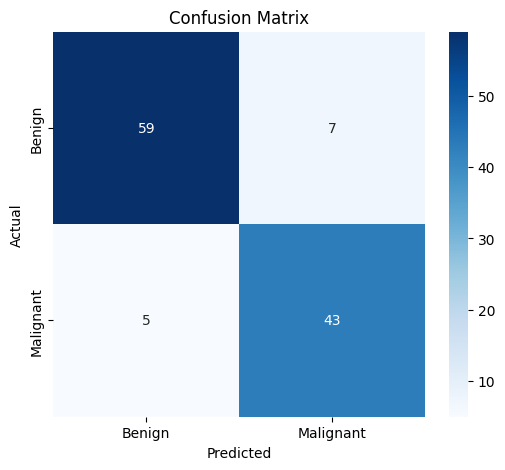

In [ ]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, predictions)

# Print it
print("Confusion Matrix:")
print(cm)
print(f"\nCorrect: {cm[0,0] + cm[1,1]}")
print(f"Wrong: {cm[0,1] + cm[1,0]}")

# Plot it
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Detailed Performance**

Accuracy:  0.89
Precision: 0.86
Recall:    0.90
F1-Score:  0.88


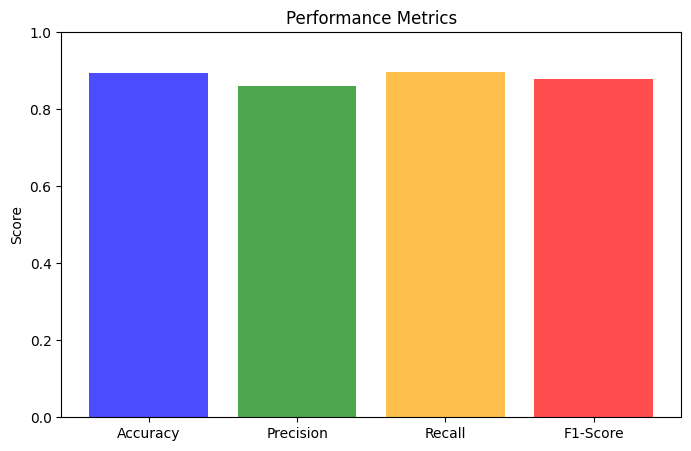

In [ ]:
# Calculate metrics
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

# Print them
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-Score:  {f1:.2f}")

# Simple bar chart
plt.figure(figsize=(8, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
plt.bar(metrics, values, color=['blue', 'green', 'orange', 'red'], alpha=0.7)
plt.ylim(0, 1)
plt.title('Performance Metrics')
plt.ylabel('Score')
plt.show()

Performance metrics when depth is 2:
Accuracy:  0.89
Precision: 0.82
Recall:    0.94
F1-Score:  0.87

Performance metrics when depth is 3:
Accuracy:  0.89
Precision: 0.88
Recall:    0.88
F1-Score:  0.88

Performance metrics when depth is 4:
Accuracy:  0.89
Precision: 0.86
Recall:    0.90
F1-Score:  0.88

Performance metrics when depth is 5:
Accuracy:  0.89
Precision: 0.86
Recall:    0.90
F1-Score:  0.88

For depth 2,3,4 & 5 accuracy is 0.89 (same)
For depth 2 Recall score is the highest (0.94).So, Depth 2 is the best depth.